In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

# SciPy 2016 Scikit-learn Tutorial

# Supervised Learning Part 1 -- Classification

To visualize the workings of machine learning algorithms, it is often helpful to study two-dimensional or one-dimensional data, that is data with only one or two features. While in practice, datasets usually have many more features, it is hard to plot high-dimensional data in on two-dimensional screens.

We will illustrate some very simple examples before we move on to more "real world" data sets.


First, we will look at a two class classification problem in two dimensions. We use the synthetic data generated by the ``make_blobs`` function.

In [2]:
from sklearn.datasets import make_blobs

X, y = make_blobs(centers=2, random_state=0) # Tạo dữ liệu mẫu với 2 cụm

print('X ~ n_samples x n_features:', X.shape)
print('y ~ n_samples:', y.shape)

print('\nFirst 5 samples:\n', X[:5, :])
print('\nFirst 5 labels:', y[:5])

X ~ n_samples x n_features: (100, 2)
y ~ n_samples: (100,)

First 5 samples:
 [[ 4.21850347  2.23419161]
 [ 0.90779887  0.45984362]
 [-0.27652528  5.08127768]
 [ 0.08848433  2.32299086]
 [ 3.24329731  1.21460627]]

First 5 labels: [1 1 0 0 1]


As the data is two-dimensional, we can plot each sample as a point in a two-dimensional coordinate system, with the first feature being the x-axis and the second feature being the y-axis.

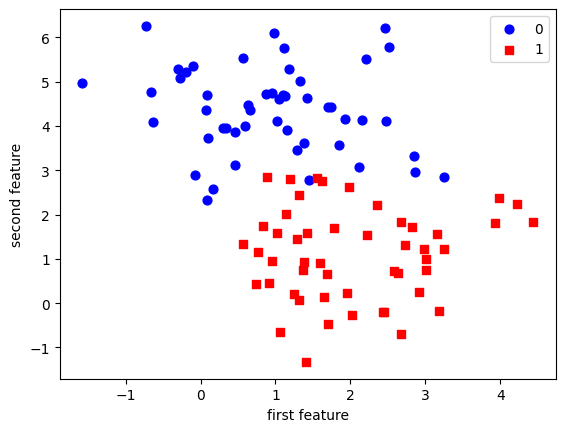

In [ ]:
plt.scatter(X[y == 0, 0], X[y == 0, 1], 
            c='blue', s=40, label='0')
plt.scatter(X[y == 1, 0], X[y == 1, 1], 
            c='red', s=40, label='1', marker='s')

plt.xlabel('first feature')
plt.ylabel('second feature')
plt.legend(loc='upper right'); 

Classification is a supervised task, and since we are interested in its performance on unseen data, we split our data into two parts:

1. a training set that the learning algorithm uses to fit the model
2. a test set to evaluate the generalization performance of the model

The ``train_test_split`` function from the ``model_selection`` module does that for us -- we will use it to split a dataset into 75% training data and 25% test data.

<img src="figures/train_test_split_matrix.svg" width="100%">


In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.25,
                                                    random_state=1234,
                                                    stratify=y)

### The scikit-learn estimator API
<img src="figures/supervised_workflow.svg" width="100%">


Every algorithm is exposed in scikit-learn via an ''Estimator'' object. (All models in scikit-learn have a very consistent interface). For instance, we first import the logistic regression class.

In [5]:
from sklearn.linear_model import LogisticRegression

Next, we instantiate the estimator object.

In [6]:
classifier = LogisticRegression()

In [7]:
X_train.shape

(75, 2)

In [10]:
y_train.shape

(75,)

To built the model from our data, that is to learn how to classify new points, we call the ``fit`` function with the training data, and the corresponding training labels (the desired output for the training data point):

In [11]:
classifier.fit(X_train, y_train)

LogisticRegression()

(Some estimator methods such as `fit` return `self` by default. Thus, after executing the code snippet above, you will see the default parameters of this particular instance of `LogisticRegression`. Another way of retrieving the estimator's ininitialization parameters is to execute `classifier.get_params()`, which returns a parameter dictionary.)

We can then apply the model to unseen data and use the model to predict the estimated outcome using the ``predict`` method:

In [14]:
prediction = classifier.predict(X_test)

We can compare these against the true labels:

In [15]:
print(prediction)
print(y_test)

[1 0 1 0 1 1 1 1 1 1 1 0 0 0 0 1 0 0 1 0 0 0 1 1 0]
[1 1 1 0 1 1 0 1 1 0 1 0 0 0 0 1 0 0 1 0 0 1 1 1 0]


We can evaluate our classifier quantitatively by measuring what fraction of predictions is correct. This is called **accuracy**:

In [16]:
np.mean(prediction == y_test)

np.float64(0.84)

There is also a convenience function , ``score``, that all scikit-learn classifiers have to compute this directly from the test data:
    

In [17]:
classifier.score(X_test, y_test)

0.84

It is often helpful to compare the generalization performance (on the test set) to the performance on the training set:

In [18]:
classifier.score(X_train, y_train)

0.9733333333333334

LogisticRegression is a so-called linear model,
that means it will create a decision that is linear in the input space. In 2d, this simply means it finds a line to separate the blue from the red:

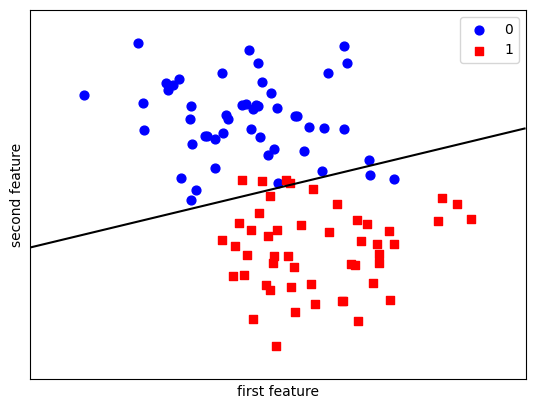

In [23]:
from figures import plot_2d_separator

plt.scatter(X[y == 0, 0], X[y == 0, 1], 
            c='blue', s=40, label='0')
plt.scatter(X[y == 1, 0], X[y == 1, 1], 
            c='red', s=40, label='1', marker='s')

plt.xlabel("first feature")
plt.ylabel("second feature")
plot_2d_separator(classifier, X)
plt.legend(loc='upper right');

**Estimated parameters**: All the estimated model parameters are attributes of the estimator object ending by an underscore. Here, these are the coefficients and the offset of the line:

In [27]:
print(classifier.coef_) # Hệ số góc của đường phân cách
print(classifier.intercept_) # Hệ số chặn của đường phân cách

[[ 0.86996884 -2.23880944]]
[4.64789844]


Another classifier: K Nearest Neighbors
------------------------------------------------
Another popular and easy to understand classifier is K nearest neighbors (kNN).  It has one of the simplest learning strategies: given a new, unknown observation, look up in your reference database which ones have the closest features and assign the predominant class.

The interface is exactly the same as for ``LogisticRegression above``.

In [28]:
from sklearn.neighbors import KNeighborsClassifier

This time we set a parameter of the KNeighborsClassifier to tell it we only want to look at one nearest neighbor:

In [29]:
knn = KNeighborsClassifier(n_neighbors=1)

We fit the model with out training data

In [30]:
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=1)

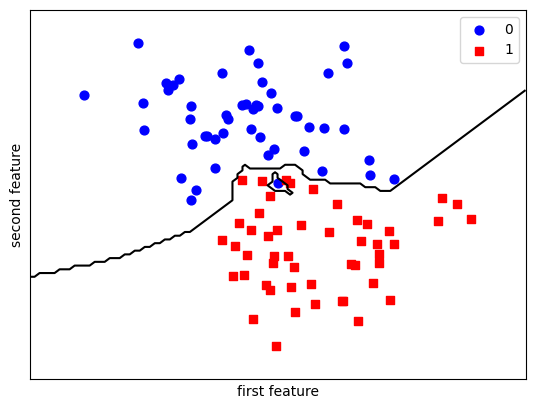

In [33]:
plt.scatter(X[y == 0, 0], X[y == 0, 1], 
            c='blue', s=40, label='0')
plt.scatter(X[y == 1, 0], X[y == 1, 1], 
            c='red', s=40, label='1', marker='s')

plt.xlabel("first feature")
plt.ylabel("second feature")
plot_2d_separator(knn, X)
plt.legend(loc='upper right');

In [34]:
knn.score(X_test, y_test)

1.0

In [37]:
predict = knn.predict(X_test)
np.mean(predict == y_test)

np.float64(1.0)

Exercise
=========
Apply the KNeighborsClassifier to the ``iris`` dataset. Play with different values of the ``n_neighbors`` and observe how training and test score change.

In [39]:
# Load data iris
from sklearn.datasets import load_iris

iris = load_iris()
X, y = iris.data, iris.target

# Sử dụng KNN với k=1
knn = KNeighborsClassifier(n_neighbors=1)

# Chia dữ liệu thành tập huấn luyện và tập kiểm tra
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.25, 
                                                    random_state=42)

# Huấn luyện mô hình
knn.fit(X_train, y_train)

# Đánh giá mô hình
knn.score(X_test, y_test)

1.0

In [62]:
# Thử nghiệm với nhiều k khác nhau 
k_values = [1, 43, 50, 70, 100]
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    accuracy = knn.score(X_test, y_test)
    print(f'Accuracy with k={k}: {accuracy:.2f}')

Accuracy with k=1: 1.00
Accuracy with k=43: 1.00
Accuracy with k=50: 0.97
Accuracy with k=70: 0.95
Accuracy with k=100: 0.29


In [63]:
# Quan sát sự thay đổi accuracy khi thay đổi k
# Ta thấy k càng lớn thì accuracy càng giảm, vì k càng lớn thì mô hình càng đơn giản, dẫn đến hiện tượng underfitting
# underfitting là hiện tượng mô hình quá đơn giản, không thể nắm bắt được các đặc điểm phức tạp của dữ liệu huấn luyện, dẫn đến hiệu suất kém trên cả dữ liệu huấn luyện và kiểm tra.


In [52]:
# %load solutions/05A_knn_with_diff_k.py